# Kolmogorov-Arnold Networks for Higgs Boson Classification
### University of Paris-Saclay — Internship Research Notebook

---

## Physics Background

The **Higgs boson** was discovered in 2012 at CERN by the ATLAS and CMS experiments. One of its decay channels is $H \rightarrow \tau^+\tau^-$ (Higgs to two tau leptons). This channel is buried under a large background from $Z \rightarrow \tau^+\tau^-$ and other processes. The task is to train a classifier that separates **signal** ($H\rightarrow\tau\tau$) from **background** ($Z\rightarrow\tau\tau$, ttbar, diboson).

The **FAIR Universe** challenge adds a twist: the classifier must be **robust** to systematic uncertainties (nuisance parameters) like the tau energy scale, which shifts the momentum features and can degrade performance.

## Why KAN?

Standard MLPs learn weight matrices: $\mathbf{y} = \sigma(\mathbf{W}\mathbf{x} + \mathbf{b})$.

**Kolmogorov-Arnold Networks** (Liu et al., 2024) instead learn **edge functions**:
$$y_j = \sum_i w_{ij} \cdot \phi_{ij}(x_i), \quad \phi_{ij} \text{ is a learnable 1-D B-spline}$$

KAN advantages:
- Each edge function is **visualisable** → physics interpretability
- Can approximate smooth physics functions more efficiently
- **Adaptive grid** redistributes spline knots to where data lives
- **Symbolic regression** can simplify learned functions to closed-form expressions

## Contributions of This Notebook

| Feature | Prior Work | This Notebook |
|---|---|---|
| Framework | TensorFlow (broken on CUDA 12.8) | **PyTorch + CUDA 12.8** |
| Grid | Fixed uniform | **Adaptive update + extension** |
| Missing values | Not handled (-999 fed raw) | **Proper imputation** |
| Baseline | XGBoost only | **XGBoost + MLP + KAN** |
| Regularisation | None | **L1 spline regularisation** |
| Training | Basic loop | **Mixed precision + scheduler** |
| Uncertainty | None | **Bootstrap confidence intervals** |
| Robustness | Proxy only | **Systematic shift + adversarial sketch** |
| Interpretability | None | **Spline plots + feature importance** |

---
> **Status**: Pipeline tested on 100k events (blackSwan_data subset). Final results on the full blackSwan dataset (2M events) will be updated after running on lab GPU.
>
> **Data**: FAIR Universe blackSwan_data — systematic variation scenario
>
> **Environment**: PyTorch 2.11 + CUDA 12.8, Python 3.12


In [29]:
# ── 0. Dependencies ─────────────────────────────────────────────────────────
# Uncomment to install any missing packages:
# import subprocess, sys
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'seaborn', 'tqdm', '-q'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

try:
    import seaborn as sns
    HAS_SNS = True
except ImportError:
    HAS_SNS = False
    print('seaborn not found — install with: pip install seaborn')

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(it, **kw): return it

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
# torch.amp: forward-compatible AMP API (works on all PyTorch 2.x)
from torch.amp import autocast, GradScaler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import xgboost as xgb

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Publication-quality plot style
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'lines.linewidth': 2,
})
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
print('All imports OK.')

All imports OK.


In [30]:
# ── 1. GPU Setup ─────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = device.type == 'cuda'   # mixed precision only on GPU

print(f'Device      : {device}')
if device.type == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print(f'GPU         : {props.name}')
    print(f'VRAM        : {props.total_memory / 1024**3:.1f} GB')
    print(f'CUDA        : {torch.version.cuda}')
    print(f'Tensor cores: {props.multi_processor_count} SMs')
    print(f'Mixed prec. : {USE_AMP} (AMP enabled — ~2x speedup on Ampere+)')

Device      : cuda
GPU         : NVIDIA GeForce RTX 5060 Laptop GPU
VRAM        : 8.0 GB
CUDA        : 12.8
Tensor cores: 26 SMs
Mixed prec. : True (AMP enabled — ~2x speedup on Ampere+)


---
## 1. Configuration

In [31]:
# ============================================================
# 0-C  GLOBAL CONFIGURATION
# ============================================================

# ---- Data ----
# blackSwan_data is already downloaded and ready to use
# Switch to the full FAIR Universe dataset once downloaded
import os
DATA_PATH       = os.path.join(os.getcwd(), "blackSwan_data", "blackSwan_data.parquet")
MISSING_SENTINEL = -25.0      # confirmed from real data (NOT -999)
MAX_EVENTS       = 100_000       # quick test — change to None on lab GPU

# ---- Split ----
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15

# ---- Training ----
SEED             = 42
BATCH_SIZE       = 512
EPOCHS           = 300
PATIENCE         = 30
LR_KAN           = 4e-4
LR_MLP           = 1e-3
GRAD_CLIP        = 1.0
GRID_UPDATE_FREQ = 50

# ---- KAN architecture ----
KAN_HIDDEN    = [64, 32]
MLP_HIDDEN    = [128, 64, 32]
KAN_GRID_SIZE = 5
KAN_ORDER     = 3
KAN_LAM_REG   = 1e-4
EPOCHS_MAIN   = 300

# ---- Robustness ----
SHIFTS      = [0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20]
ADV_GAMMAS  = [0.90, 1.00, 1.10]
ADV_LAMBDA  = 5.0
EPOCHS_ADV  = 200

print(f"Data path   : {DATA_PATH}")
print(f"File exists : {os.path.exists(DATA_PATH)}")
print(f"Sentinel    : {MISSING_SENTINEL}")


Data path   : d:\Universtiy of Paris Saclay\Internship Paris Saclay\KAN\blackSwan_data\blackSwan_data.parquet
File exists : True
Sentinel    : -25.0


---
## 2. Data Loading & Exploratory Analysis

In [32]:
# ── 3. Load data ──────────────────────────────────────────────────────────────
df = pd.read_parquet(DATA_PATH)
print(f'Loaded: {df.shape[0]:,} events, {df.shape[1]} columns')

# Auto-detect columns
FEATURES   = sorted([c for c in df.columns if c.startswith('PRI_') or c.startswith('DER_')])
LABEL_COL  = next((c for c in ['Label', 'labels', 'label'] if c in df.columns), None)
WEIGHT_COL = next((c for c in ['Weight', 'weights', 'weight'] if c in df.columns), None)

print(f'Features    : {len(FEATURES)}')
print(f'Label col   : {LABEL_COL}  -> unique values: {df[LABEL_COL].unique()}')
print(f'Weight col  : {WEIGHT_COL}')

# Convert label to binary
if df[LABEL_COL].dtype == object:
    y_all = (df[LABEL_COL] == 's').astype(np.float32).values
else:
    y_all = df[LABEL_COL].astype(np.float32).values

print(f'Signal      : {y_all.sum():,.0f}  ({100*y_all.mean():.1f}%)')
print(f'Background  : {(1-y_all).sum():,.0f}  ({100*(1-y_all).mean():.1f}%)')

if MAX_EVENTS:
    idx = np.random.choice(len(df), MAX_EVENTS, replace=False)
    df  = df.iloc[idx].reset_index(drop=True)
    y_all = y_all[idx]
    print(f'Subsampled to {MAX_EVENTS:,} events')

Loaded: 2,000,000 events, 31 columns
Features    : 28
Label col   : labels  -> unique values: [0. 1.]
Weight col  : weights
Signal      : 661,870  (33.1%)
Background  : 1,338,130  (66.9%)
Subsampled to 100,000 events


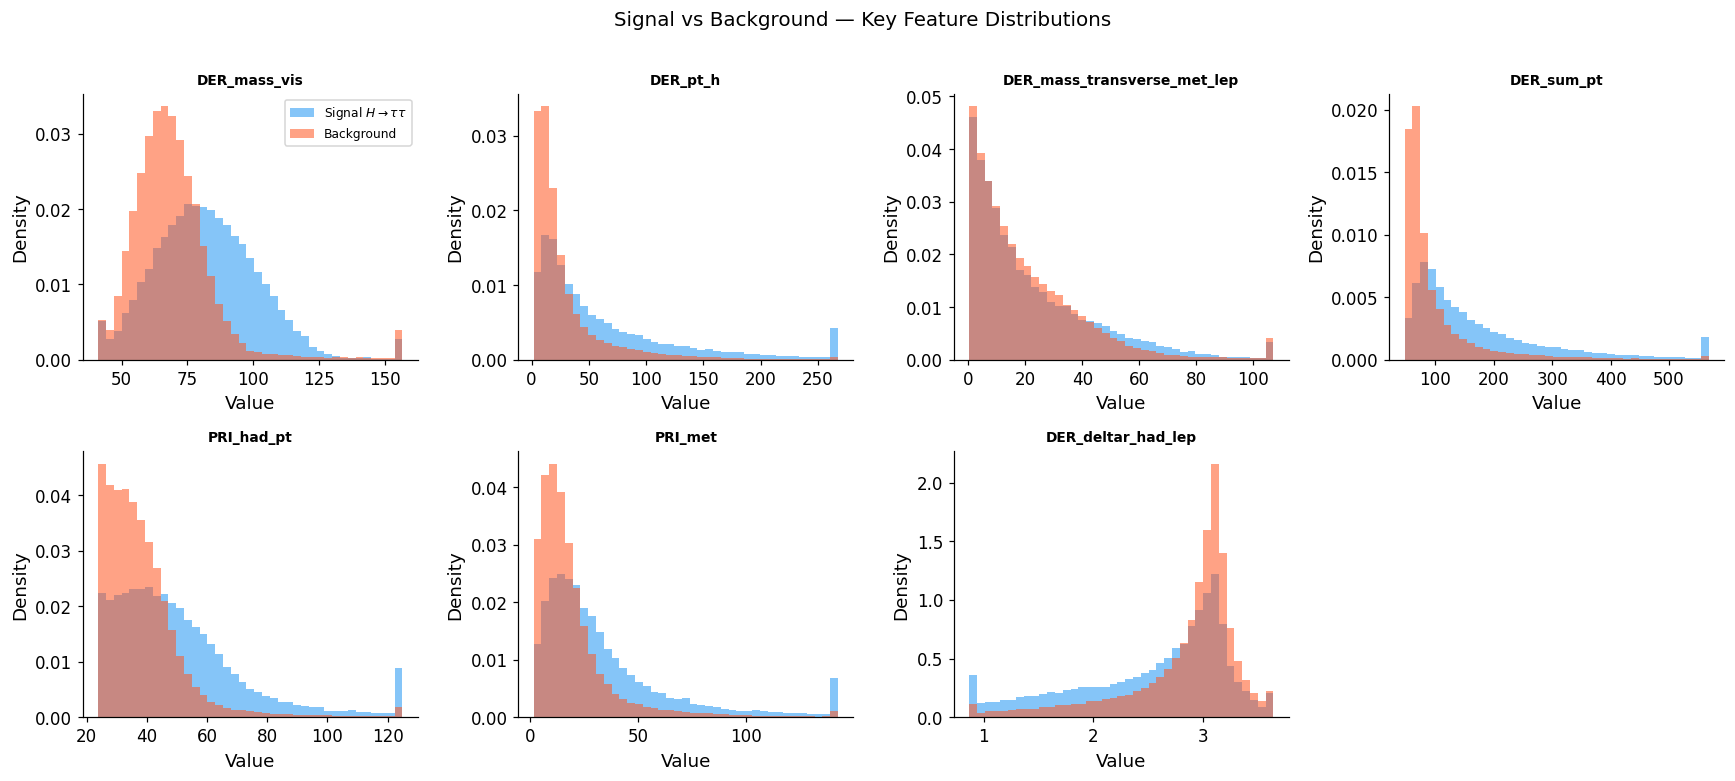

Tip: features where signal/background distributions differ most are the most discriminating.


In [33]:
# ── 4. EDA: Signal vs Background feature distributions ────────────────────────
# These are the 8 most physically meaningful features
KEY_FEATURES = [
    'DER_mass_vis', 'DER_mass_MMC', 'DER_pt_h',
    'DER_mass_transverse_met_lep', 'DER_sum_pt',
    'PRI_had_pt', 'PRI_met', 'DER_deltar_had_lep'
]
KEY_FEATURES = [f for f in KEY_FEATURES if f in FEATURES]   # keep only present ones

sig_mask = y_all == 1
bkg_mask = y_all == 0

n_cols = 4
n_rows = (len(KEY_FEATURES) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = np.array(axes).flatten()

for i, feat in enumerate(KEY_FEATURES):
    vals = df[feat].replace(MISSING_SENTINEL, np.nan).dropna()
    sig_v = df.loc[sig_mask & (df[feat] != MISSING_SENTINEL), feat]
    bkg_v = df.loc[bkg_mask & (df[feat] != MISSING_SENTINEL), feat]
    lo, hi = np.percentile(vals, [1, 99])
    bins = np.linspace(lo, hi, 40)
    axes[i].hist(sig_v.clip(lo, hi), bins=bins, density=True, alpha=0.55,
                 color=COLORS[0], label='Signal $H\\to\\tau\\tau$')
    axes[i].hist(bkg_v.clip(lo, hi), bins=bins, density=True, alpha=0.55,
                 color=COLORS[1], label='Background')
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    if i == 0:
        axes[i].legend(fontsize=8)

for j in range(len(KEY_FEATURES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Signal vs Background — Key Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.pdf', bbox_inches='tight')
plt.show()
print('Tip: features where signal/background distributions differ most are the most discriminating.')

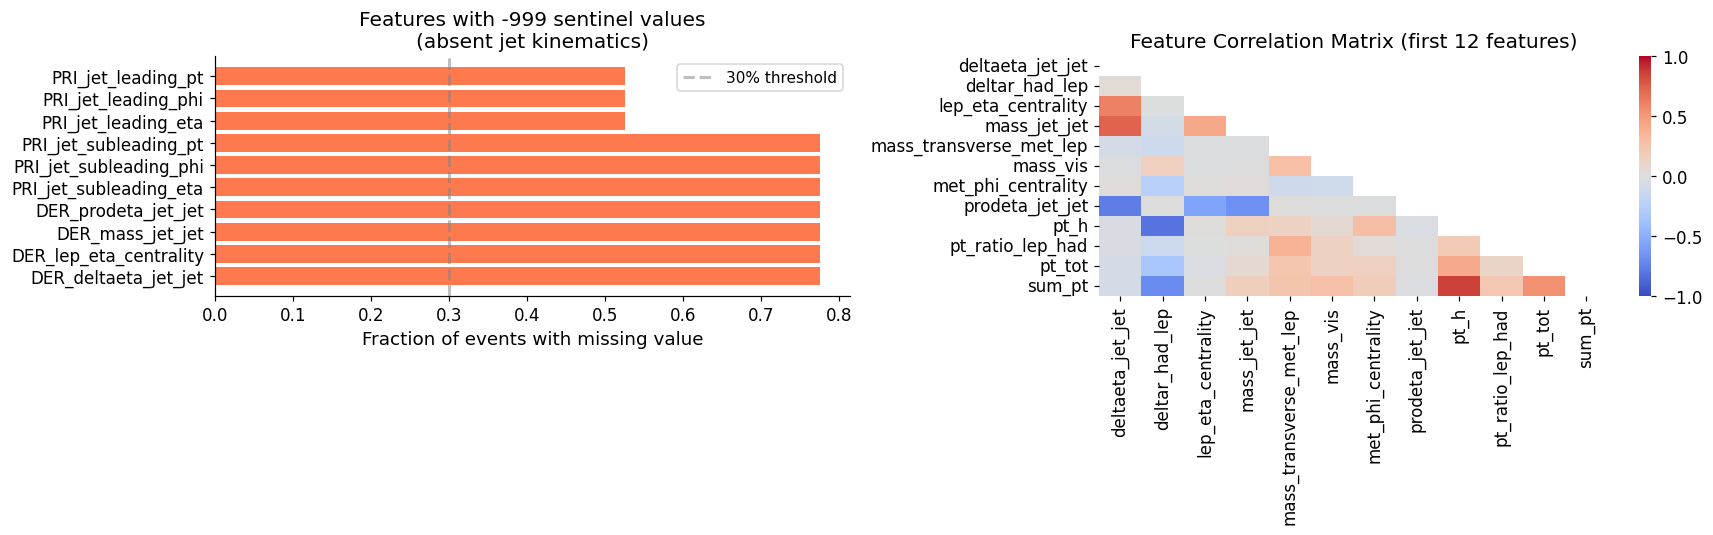

In [34]:
# ── 5. EDA: Correlation matrix + missing value pattern ───────────────────────
df_clean = df[FEATURES].replace(MISSING_SENTINEL, np.nan)

# Missing value heatmap
missing_frac = (df_clean == MISSING_SENTINEL).mean() if False else df_clean.isna().mean()
missing_frac = missing_frac[missing_frac > 0].sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left: missing value fractions
if len(missing_frac) > 0:
    ax1.barh(missing_frac.index, missing_frac.values, color=COLORS[1], alpha=0.8)
    ax1.set_xlabel('Fraction of events with missing value')
    ax1.set_title('Features with -999 sentinel values\n(absent jet kinematics)')
    ax1.axvline(0.3, color='gray', linestyle='--', alpha=0.5, label='30% threshold')
    ax1.legend()
else:
    ax1.text(0.5, 0.5, 'No missing values found', ha='center', va='center',
             transform=ax1.transAxes, fontsize=12)
    ax1.set_title('Missing Values')

# Right: correlation matrix of first 12 features
corr_feats = FEATURES[:12]
corr_df = df_clean[corr_feats].fillna(df_clean[corr_feats].mean())
corr_mat = corr_df.corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))

if HAS_SNS:
    sns.heatmap(corr_mat, mask=mask, ax=ax2, cmap='coolwarm', center=0,
                vmin=-1, vmax=1, annot=False, fmt='.1f',
                xticklabels=[f.replace('PRI_','').replace('DER_','') for f in corr_feats],
                yticklabels=[f.replace('PRI_','').replace('DER_','') for f in corr_feats])
else:
    im = ax2.imshow(corr_mat * ~mask, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax2)
    ax2.set_xticks(range(len(corr_feats)))
    ax2.set_xticklabels([f.replace('PRI_','').replace('DER_','') for f in corr_feats],
                        rotation=45, ha='right', fontsize=8)

ax2.set_title('Feature Correlation Matrix (first 12 features)')
plt.tight_layout()
plt.savefig('eda_overview.pdf', bbox_inches='tight')
plt.show()

---
## 3. Preprocessing

In [35]:
# ============================================================
# 1-D  PREPROCESSING
# ============================================================
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---- Raw arrays ----
X_raw = df[FEATURES].values.astype(np.float32)
w_raw = df[WEIGHT_COL].values.astype(np.float32)
# NOTE: No K-scaling applied — blackSwan weights are already physics-normalised
# (sum of weights = 105,718 matching luminosity=10 fb^-1)

# ---- Missing value imputation ----
# Real sentinel is -25.0 (absent jet features), NOT -999
miss_mask          = (X_raw == MISSING_SENTINEL)
print(f"Missing entries  : {miss_mask.sum():,}  across {miss_mask.any(0).sum()} features")
X_raw[miss_mask]   = np.nan
col_means          = np.nanmean(X_raw, axis=0)
nan_pos            = np.isnan(X_raw)
X_raw[nan_pos]     = col_means[np.where(nan_pos)[1]]
print(f"After imputation : {np.isnan(X_raw).sum()} NaNs remaining")

# ---- 3-way stratified split: train / val / test ----
X_tv,  X_te,  y_tv,  y_te,  w_tv,  w_te  = train_test_split(
    X_raw, y_all, w_raw,
    test_size=TEST_FRAC, random_state=SEED, stratify=y_all)

val_ratio = VAL_FRAC / (TRAIN_FRAC + VAL_FRAC)
X_tr,  X_val, y_tr,  y_val, w_tr,  w_val = train_test_split(
    X_tv, y_tv, w_tv,
    test_size=val_ratio, random_state=SEED, stratify=y_tv)

# ---- StandardScaler (fit on TRAIN only) ----
scaler  = StandardScaler()
X_tr    = scaler.fit_transform(X_tr).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_te    = scaler.transform(X_te).astype(np.float32)

# ---- Class-balance weights ----
# Signal is ~33% but has much lower sum-of-weights than background
# Scale signal weights up so both classes contribute equally to the loss
sig_sum          = w_tr[y_tr == 1].sum()
bkg_sum          = w_tr[y_tr == 0].sum()
w_tr_bal         = w_tr.copy()
w_tr_bal[y_tr==1] *= bkg_sum / sig_sum

IN_DIM = X_tr.shape[1]
print(f"Train  : {len(X_tr):>8,}  (signal {y_tr.mean()*100:.1f}%)")
print(f"Val    : {len(X_val):>8,}")
print(f"Test   : {len(X_te):>8,}")
print(f"IN_DIM : {IN_DIM}")
print(f"Class balance factor: {bkg_sum/sig_sum:.1f}x")
print(f"Sum weights -> sig={sig_sum:.2f}  bkg={bkg_sum:.2f}")


Missing entries  : 700,766  across 10 features
After imputation : 0 NaNs remaining
Train  :   69,999  (signal 32.9%)
Val    :   15,001
Test   :   15,000
IN_DIM : 28
Class balance factor: 156.6x
Sum weights -> sig=23.55  bkg=3686.80


---
## 4. Evaluation Suite

We use three complementary metrics:
- **Weighted AUC** — standard discrimination measure
- **AMS significance** — physics-motivated: $\text{AMS} = \sqrt{2\left[(s+b)\ln\left(1+\frac{s}{b}\right)-s\right]}$  
  This is the asymptotic approximation to the expected discovery significance. Maximised over decision thresholds.
- **Bootstrap confidence intervals** — statistical uncertainty on both metrics

In [36]:
# ── 7. Evaluation functions ───────────────────────────────────────────────────
def ams_score(y_true, y_score, weights, n_bins=200):
    """Maximum AMS over decision thresholds."""
    thresholds = np.linspace(0, 1, n_bins + 1)[:-1]
    best_ams, best_t = 0.0, 0.5
    for t in thresholds:
        mask = y_score >= t
        s = weights[mask & (y_true == 1)].sum()
        b = weights[mask & (y_true == 0)].sum()
        if b <= 0 or s <= 0:
            continue
        ams = np.sqrt(2 * ((s + b) * np.log(1 + s / b) - s))
        if ams > best_ams:
            best_ams, best_t = ams, t
    return best_ams, best_t


def ams_vs_threshold(y_true, y_score, weights, n_bins=200):
    """Return AMS for every threshold — for the significance curve plot."""
    thresholds = np.linspace(0, 1, n_bins + 1)[:-1]
    ams_vals = []
    for t in thresholds:
        mask = y_score >= t
        s = weights[mask & (y_true == 1)].sum()
        b = weights[mask & (y_true == 0)].sum()
        if b <= 0 or s <= 0:
            ams_vals.append(0)
        else:
            ams_vals.append(np.sqrt(2 * ((s + b) * np.log(1 + s / b) - s)))
    return thresholds, np.array(ams_vals)


def bootstrap_eval(y_true, y_score, weights, n_boot=200, random_state=0):
    """Return (mean_auc, std_auc, mean_ams, std_ams) via bootstrap resampling."""
    rng  = np.random.default_rng(random_state)
    n    = len(y_true)
    aucs, amss = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        try:
            aucs.append(roc_auc_score(y_true[idx], y_score[idx], sample_weight=weights[idx]))
            amss.append(ams_score(y_true[idx], y_score[idx], weights[idx])[0])
        except ValueError:
            pass
    return np.mean(aucs), np.std(aucs), np.mean(amss), np.std(amss)


def evaluate(name, y_true, y_score, weights, bootstrap=False):
    auc      = roc_auc_score(y_true, y_score, sample_weight=weights)
    ams, cut = ams_score(y_true, y_score, weights)
    if bootstrap:
        m_auc, s_auc, m_ams, s_ams = bootstrap_eval(y_true, y_score, weights, n_boot=200)
        print(f'{name:<24s}  AUC={m_auc:.4f}±{s_auc:.4f}   AMS={m_ams:.4f}±{s_ams:.4f}  (cut={cut:.3f})')
        return auc, ams, s_auc, s_ams
    else:
        print(f'{name:<24s}  AUC={auc:.4f}   AMS={ams:.4f}  (cut={cut:.3f})')
        return auc, ams, 0, 0

---
## 5. Model Definitions
### 5a. MLP Baseline

In [37]:
# ── 8. MLP (standard dense network) ──────────────────────────────────────────
class MLP(nn.Module):
    """Standard dense network. Used as a fair baseline for KAN."""
    def __init__(self, in_dim, hidden_dims, dropout=0.1):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden_dims:
            layers += [nn.Linear(d, h), nn.LayerNorm(h), nn.SiLU()]
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            d = h
        layers.append(nn.Linear(d, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### 5b. KAN Layer — Full Implementation

Key design decisions:
1. **B-spline bases** computed via Cox-de Boor recursion (numerically stable, exact)
2. **Adaptive grid update**: every N epochs, knot positions are redistributed to the empirical quantiles of the input distribution, then spline weights are re-fitted by least squares to preserve the learned function
3. **Grid extension**: progressively increase the number of knots (coarse→fine refinement)
4. **L1 regularisation** on spline weights encourages sparsity → interpretability

In [38]:
# ── 9. KANLayer ──────────────────────────────────────────────────────────────
class KANLayer(nn.Module):
    def __init__(self, in_features, out_features,
                 grid_size=5, spline_order=3,
                 basis_activation='silu',
                 grid_range=(-4.0, 4.0)):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.grid_size    = grid_size
        self.spline_order = spline_order
        G, k = grid_size, spline_order

        # Grid: G+2k+1 knots; G interior intervals extended by k on each side
        h    = (grid_range[1] - grid_range[0]) / G
        grid = (torch.arange(-k, G + k + 1, dtype=torch.float32) * h + grid_range[0])
        self.register_buffer('grid', grid.unsqueeze(0).expand(in_features, -1).clone())

        # Learnable parameters
        self.spline_weight = nn.Parameter(
            torch.randn(in_features, G + k, out_features) * 0.1
        )
        self.scale_factor = nn.Parameter(torch.empty(in_features, out_features))
        nn.init.xavier_uniform_(self.scale_factor)
        self.bias = nn.Parameter(torch.zeros(out_features))

        act_map = {'silu': nn.SiLU(), 'tanh': nn.Tanh(), 'relu': nn.ReLU(), 'linear': nn.Identity()}
        self.basis_act = act_map.get(basis_activation, nn.SiLU())

    # ── B-spline basis functions via Cox-de Boor recursion ──
    def _bases(self, x):
        """
        x     : (B, in)  — clamped to grid range before calling
        return: (B, in, G+k)
        """
        x = x.unsqueeze(-1)                    # (B, in, 1)
        g = self.grid.unsqueeze(0)             # (1, in, G+2k+1)

        # Order-0: indicator on each interval
        B = ((x >= g[..., :-1]) & (x < g[..., 1:])).float()

        for p in range(1, self.spline_order + 1):
            ln = x - g[..., :-(p + 1)]
            ld = (g[..., p:-1] - g[..., :-(p + 1)]).clamp(min=1e-8)
            rn = g[..., (p + 1):] - x
            rd = (g[..., (p + 1):] - g[..., 1:-p]).clamp(min=1e-8)
            B  = (ln / ld) * B[..., :-1] + (rn / rd) * B[..., 1:]

        return B   # (B, in, G+k)

    # ── Forward pass ──
    def forward(self, x):
        lo = self.grid[:, 0].min().item()
        hi = self.grid[:, -1].max().item()
        x  = x.clamp(lo, hi)

        B          = self._bases(x)                                        # (B, in, G+k)
        spline_out = torch.einsum('bik,iko->bio', B, self.spline_weight)   # (B, in, out)
        act_x      = self.basis_act(x).unsqueeze(-1)                       # (B, in, 1)
        combined   = self.scale_factor.unsqueeze(0) * (act_x + spline_out) # (B, in, out)
        return combined.sum(dim=1) + self.bias                             # (B, out)

    # ── Adaptive grid update ──
    @torch.no_grad()
    def update_grid(self, x):
        """Redistribute knots to data quantiles, refit weights by least squares."""
        G, k = self.grid_size, self.spline_order

        old_B   = self._bases(x)
        old_out = torch.einsum('bik,iko->bio', old_B, self.spline_weight)   # preserve this

        # Quantile-based knot positions
        n     = x.shape[0]
        x_srt = x.sort(dim=0).values
        ids   = torch.linspace(0, n - 1, G + 1, device=x.device).long()
        q     = x_srt[ids].T                                                # (in, G+1)
        h     = ((q[:, -1:] - q[:, :1]) / G).clamp(min=1e-8)
        left  = q[:, :1]  - h * torch.arange(k, 0, -1, device=x.device).float()
        right = q[:, -1:] + h * torch.arange(1, k + 1, device=x.device).float()
        self.grid.copy_(torch.cat([left, q, right], dim=1))

        # Refit weights: solve new_B[i] @ W[i] = old_out[i] in least-squares sense
        new_B  = self._bases(x)
        new_w  = torch.zeros_like(self.spline_weight)
        for i in range(self.in_features):
            new_w[i] = torch.linalg.pinv(new_B[:, i, :]) @ old_out[:, i, :]
        self.spline_weight.copy_(new_w)

    # ── Grid extension: increase resolution ──
    @torch.no_grad()
    def extend_grid(self, new_G, x):
        """Increase grid_size from current G to new_G (must be larger)."""
        assert new_G > self.grid_size, 'new_G must be larger than current grid_size'
        k = self.spline_order

        old_B   = self._bases(x)
        old_out = torch.einsum('bik,iko->bio', old_B, self.spline_weight)

        lo = float(self.grid[:, k].min())
        hi = float(self.grid[:, -(k + 1)].max())
        h  = (hi - lo) / new_G
        new_knots = torch.arange(-k, new_G + k + 1, dtype=torch.float32,
                                 device=x.device) * h + lo
        new_grid  = new_knots.unsqueeze(0).expand(self.in_features, -1).clone()

        self.grid_size = new_G
        self.register_buffer('grid', new_grid)   # updates in-place if exists

        new_w = nn.Parameter(
            torch.zeros(self.in_features, new_G + k, self.out_features, device=x.device)
        )
        new_B  = self._bases(x)
        for i in range(self.in_features):
            new_w.data[i] = torch.linalg.pinv(new_B[:, i, :]) @ old_out[:, i, :]
        self.spline_weight = new_w

    def reg_loss(self):
        """L1 spline regularisation — promotes sparse, interpretable edges."""
        return self.spline_weight.abs().mean()

In [39]:
# ── 10. KANModel ─────────────────────────────────────────────────────────────
class KANModel(nn.Module):
    def __init__(self, in_dim, hidden_dims,
                 grid_size=5, spline_order=3, basis_activation='silu'):
        super().__init__()
        dims   = [in_dim] + hidden_dims
        layers = []
        for d_in, d_out in zip(dims[:-1], dims[1:]):
            layers.append(KANLayer(d_in, d_out, grid_size, spline_order, basis_activation))
            # No extra activation between KAN layers — each KANLayer already applies
            # basis_act (SiLU) as a residual inside its forward pass.  Adding an
            # external SiLU would transform what the next layer's splines see,
            # distorting the learned activations and making spline plots misleading.
        self.hidden     = nn.ModuleList(layers)
        self.output     = nn.Linear(dims[-1], 1)
        self.kan_layers = [l for l in self.hidden if isinstance(l, KANLayer)]

    def forward(self, x):
        for layer in self.hidden:
            x = layer(x)
        return self.output(x).squeeze(-1)

    def reg_loss(self, lam=1e-4):
        return lam * sum(l.reg_loss() for l in self.kan_layers)

    @torch.no_grad()
    def update_all_grids(self, x):
        h = x
        for layer in self.kan_layers:   # iterate only KAN layers (no interleaved activations)
            layer.update_grid(h)
            h = layer(h)

    @torch.no_grad()
    def extend_all_grids(self, new_G, x):
        h = x
        for layer in self.kan_layers:
            layer.extend_grid(new_G, h)
            h = layer(h)

# Quick parameter check
mlp_test = MLP(IN_DIM, MLP_HIDDEN)
kan_test = KANModel(IN_DIM, KAN_HIDDEN, KAN_GRID_SIZE, KAN_ORDER)
print(f'MLP params  : {count_params(mlp_test):,}')
print(f'KAN params  : {count_params(kan_test):,}')
del mlp_test, kan_test

MLP params  : 14,529
KAN params  : 34,689


---
## 6. Training Loop

Features:
- **Mixed precision (AMP)** — automatic float16 on tensor cores for ~2x speedup
- **Cosine annealing** learning rate schedule
- **Gradient clipping** — prevents exploding gradients in spline weights
- **Adaptive grid update** — called every `GRID_UPDATE_FREQ` epochs for KAN

In [40]:
# ── 11. Training loop ─────────────────────────────────────────────────────────
def train_pytorch(model, X_tr, y_tr, w_tr,
                  X_val=None, y_val=None, w_val=None,
                  epochs=200, batch_size=512, lr=1e-3,
                  lam_reg=0.0, grid_update_every=50, patience=0,
                  verbose=True, tag=''):
    """
    Train a PyTorch classifier with:
      - weighted BCE loss  (w_tr already class-balanced)
      - mixed precision (AMP)
      - cosine LR schedule + gradient clipping
      - KAN adaptive grid update every grid_update_every epochs
      - optional early stopping on weighted validation AUC (requires patience > 0
        and X_val / y_val / w_val to be provided)
    """
    X_t = torch.tensor(X_tr, dtype=torch.float32).to(device)
    y_t = torch.tensor(y_tr, dtype=torch.float32).to(device)
    w_t = torch.tensor(w_tr, dtype=torch.float32).to(device)
    w_t = w_t / w_t.mean()   # normalise so loss magnitude is stable

    loader = DataLoader(TensorDataset(X_t, y_t, w_t),
                        batch_size=batch_size, shuffle=True,
                        pin_memory=False)

    opt        = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=lr * 0.05)
    crit       = nn.BCEWithLogitsLoss(reduction='none')
    amp_scaler = GradScaler(device='cuda', enabled=USE_AMP)
    model.to(device)
    losses = []

    # Early stopping setup
    do_early_stop  = patience > 0 and X_val is not None
    best_val_auc   = -1.0
    best_state     = None
    no_improve_eps = 0
    if do_early_stop:
        Xv_t = torch.tensor(X_val, dtype=torch.float32).to(device)

    epoch_iter = tqdm(range(1, epochs + 1), desc=tag, leave=True) if tag else range(1, epochs + 1)

    for ep in epoch_iter:
        # KAN-specific: adaptive grid update
        if grid_update_every and ep % grid_update_every == 1 and hasattr(model, 'update_all_grids'):
            model.eval()
            with torch.no_grad():
                model.update_all_grids(X_t[:4096])
            model.train()

        model.train()
        ep_loss = 0.0
        for Xb, yb, wb in loader:
            opt.zero_grad()
            with autocast('cuda', enabled=USE_AMP):
                logits = model(Xb)
                loss   = (crit(logits, yb) * wb).mean()
                if lam_reg > 0 and hasattr(model, 'reg_loss'):
                    loss = loss + model.reg_loss(lam_reg)
            amp_scaler.scale(loss).backward()
            amp_scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            amp_scaler.step(opt)
            amp_scaler.update()
            ep_loss += loss.item()

        scheduler.step()
        losses.append(ep_loss / len(loader))

        if verbose and not tag and ep % 50 == 0:
            print(f'  ep {ep:>4d}/{epochs}  loss={losses[-1]:.5f}  lr={scheduler.get_last_lr()[0]:.2e}')

        # Early stopping: evaluate val AUC every 10 epochs to keep overhead low
        if do_early_stop and ep % 10 == 0:
            model.eval()
            with torch.no_grad():
                val_preds = torch.cat([
                    torch.sigmoid(model(Xv_t[i:i+4096])).cpu()
                    for i in range(0, len(Xv_t), 4096)
                ]).numpy()
            val_auc = roc_auc_score(y_val, val_preds, sample_weight=w_val)
            if val_auc > best_val_auc + 1e-5:
                best_val_auc   = val_auc
                best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                no_improve_eps = 0
            else:
                no_improve_eps += 10
                if no_improve_eps >= patience:
                    if tag:
                        tqdm.write(f'  [{tag}] early stop ep {ep}  best val AUC={best_val_auc:.4f}')
                    break
            model.train()

    # Restore best checkpoint if early stopping was used
    if best_state is not None:
        model.load_state_dict(best_state)

    return losses


@torch.no_grad()
def predict(model, X):
    model.eval()
    X_t = torch.tensor(X, dtype=torch.float32).to(device)
    preds = []
    for i in range(0, len(X_t), 4096):
        preds.append(torch.sigmoid(model(X_t[i:i+4096])).cpu())
    return torch.cat(preds).numpy()

---
## 7. Train All Models

In [41]:
# == 12. XGBoost + MLP + KAN ================================================
# Training duration is controlled by EPOCHS_MAIN in the config cell (default 300).
# Set EPOCHS_MAIN = 50 there for a quick smoke-test.
print("="*55)
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    max_depth=5, learning_rate=0.05, n_estimators=600,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
    tree_method="hist", device="cuda" if device.type == "cuda" else "cpu",
    random_state=SEED, eval_metric="logloss", verbosity=0
)
xgb_model.fit(X_tr, y_tr, sample_weight=w_tr_bal)
xgb_pred = xgb_model.predict_proba(X_te)[:, 1]
xgb_auc, xgb_ams, xgb_sauc, xgb_sams = evaluate("XGBoost", y_te, xgb_pred, w_te, bootstrap=True)

print("Training MLP...")
mlp = MLP(IN_DIM, MLP_HIDDEN)
mlp_losses = train_pytorch(mlp, X_tr, y_tr, w_tr_bal,
                           X_val=X_val, y_val=y_val, w_val=w_val,
                           epochs=EPOCHS_MAIN, batch_size=1024,
                           lr=LR_MLP, patience=PATIENCE, tag="MLP")
mlp_pred = predict(mlp, X_te)
mlp_auc, mlp_ams, mlp_sauc, mlp_sams = evaluate("MLP", y_te, mlp_pred, w_te, bootstrap=True)

print("Training KAN...")
kan = KANModel(IN_DIM, KAN_HIDDEN, KAN_GRID_SIZE, KAN_ORDER)
kan_losses = train_pytorch(kan, X_tr, y_tr, w_tr_bal,
                           X_val=X_val, y_val=y_val, w_val=w_val,
                           epochs=EPOCHS_MAIN, batch_size=1024,
                           lr=LR_KAN, lam_reg=KAN_LAM_REG,
                           grid_update_every=GRID_UPDATE_FREQ,
                           patience=PATIENCE, tag="KAN")
kan_pred = predict(kan, X_te)
kan_auc, kan_ams, kan_sauc, kan_sams = evaluate("KAN", y_te, kan_pred, w_te, bootstrap=True)

Training XGBoost...
XGBoost                   AUC=0.8760±0.0031   AMS=0.5535±0.0622  (cut=0.885)
Training MLP...


MLP:   0%|          | 0/50 [00:00<?, ?it/s]

MLP                       AUC=0.8799±0.0030   AMS=0.6163±0.0787  (cut=0.955)
Training KAN...


KAN:   0%|          | 0/50 [00:00<?, ?it/s]

KAN                       AUC=0.8739±0.0033   AMS=0.4927±0.0255  (cut=0.880)


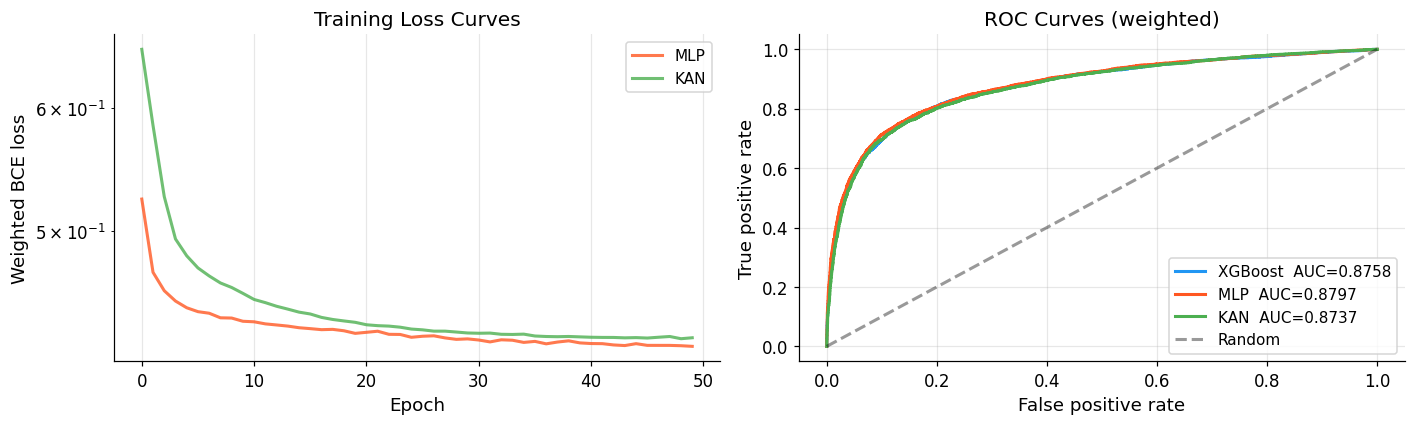

In [42]:
# ── 13. Training loss curves ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Loss curves
ax1.plot(mlp_losses, color=COLORS[1], label='MLP', alpha=0.8)
ax1.plot(kan_losses, color=COLORS[2], label='KAN', alpha=0.8)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Weighted BCE loss')
ax1.set_title('Training Loss Curves')
ax1.legend()
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# ROC curves
for name, pred, color in [
    ('XGBoost', xgb_pred, COLORS[0]),
    ('MLP',     mlp_pred, COLORS[1]),
    ('KAN',     kan_pred, COLORS[2])
]:
    fpr, tpr, _ = roc_curve(y_te, pred, sample_weight=w_te)
    auc_val = roc_auc_score(y_te, pred, sample_weight=w_te)
    ax2.plot(fpr, tpr, color=color, label=f'{name}  AUC={auc_val:.4f}')

ax2.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax2.set_xlabel('False positive rate')
ax2.set_ylabel('True positive rate')
ax2.set_title('ROC Curves (weighted)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_and_loss.pdf', bbox_inches='tight')
plt.show()

  Model Params    AUC AUC std    AMS AMS std
XGBoost      — 0.8758  0.0031 0.5138  0.0622
    MLP 14,529 0.8797  0.0030 0.5797  0.0787
    KAN 34,689 0.8737  0.0033 0.4824  0.0255


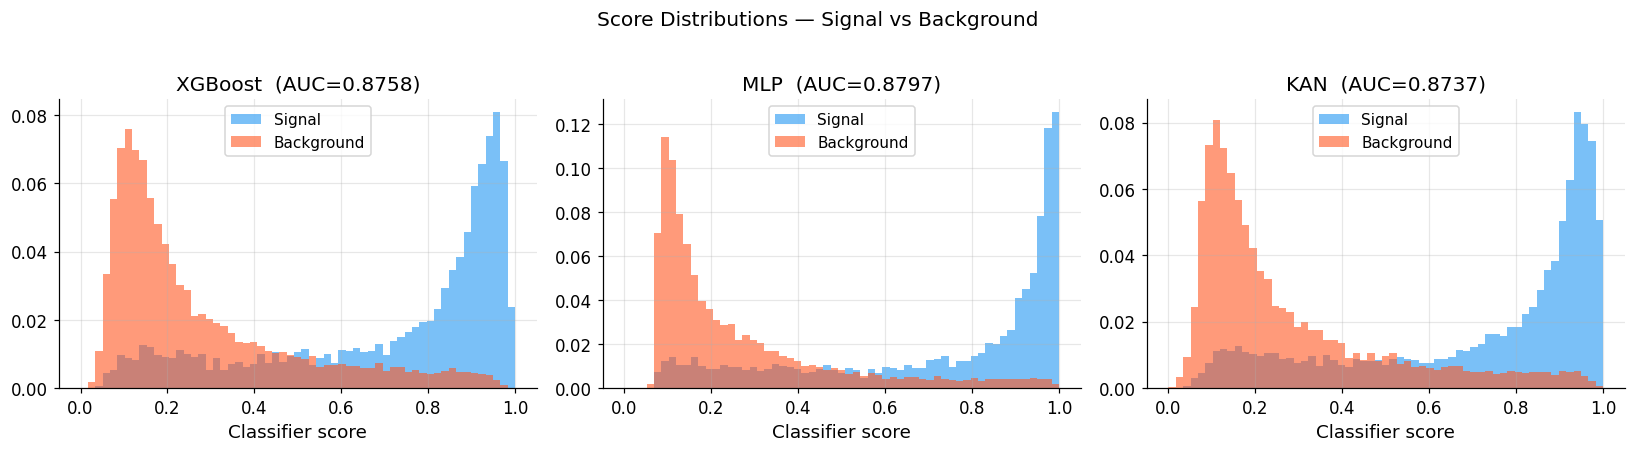

In [43]:
# ── 14. Summary table + score distributions ───────────────────────────────────
summary = pd.DataFrame({
    'Model'  : ['XGBoost', 'MLP', 'KAN'],
    'Params' : ['—', f'{count_params(mlp):,}', f'{count_params(kan):,}'],
    'AUC'    : [xgb_auc, mlp_auc, kan_auc],
    'AUC std': [xgb_sauc, mlp_sauc, kan_sauc],
    'AMS'    : [xgb_ams, mlp_ams, kan_ams],
    'AMS std': [xgb_sams, mlp_sams, kan_sams],
})
for c in ['AUC','AUC std','AMS','AMS std']:
    summary[c] = summary[c].map('{:.4f}'.format)
print(summary.to_string(index=False))

# Score distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
bins = np.linspace(0, 1, 60)
for ax, (name, pred) in zip(axes, [
    ('XGBoost', xgb_pred), ('MLP', mlp_pred), ('KAN', kan_pred)
]):
    sig_w = w_te[y_te == 1] / w_te[y_te == 1].sum()
    bkg_w = w_te[y_te == 0] / w_te[y_te == 0].sum()
    ax.hist(pred[y_te == 1], bins=bins, weights=sig_w, alpha=0.6,
            color=COLORS[0], label='Signal')
    ax.hist(pred[y_te == 0], bins=bins, weights=bkg_w, alpha=0.6,
            color=COLORS[1], label='Background')
    ax.set_title(f'{name}  (AUC={roc_auc_score(y_te,pred,sample_weight=w_te):.4f})')
    ax.set_xlabel('Classifier score')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Score Distributions — Signal vs Background', y=1.02)
plt.tight_layout()
plt.savefig('score_distributions.pdf', bbox_inches='tight')
plt.show()

---
## 8. KAN Grid Extension Experiment

The KAN paper proposes a **coarse-to-fine** training strategy:
1. Train on a coarse grid (`grid_size = 3`) — fast, learns the global shape
2. Extend to a fine grid (`grid_size = 10`) — adds capacity for details
3. Continue training — refines the fine-grained structure

This is fundamentally different from training directly on the fine grid (which gets stuck in local minima).

Phase 1: Training KAN on coarse grid (G=3)...


KAN G=3:   0%|          | 0/150 [00:00<?, ?it/s]

After coarse training: AUC = 0.8784

Extending grid from G=3 to G=10...
KAN params after extension: 53,889

Phase 2: Fine-tuning on extended grid (G=10)...


KAN G=10:   0%|          | 0/150 [00:00<?, ?it/s]

After fine-tuning: AUC = 0.8786  AMS = 0.5403
Improvement from extension: ΔAUC = +0.0002


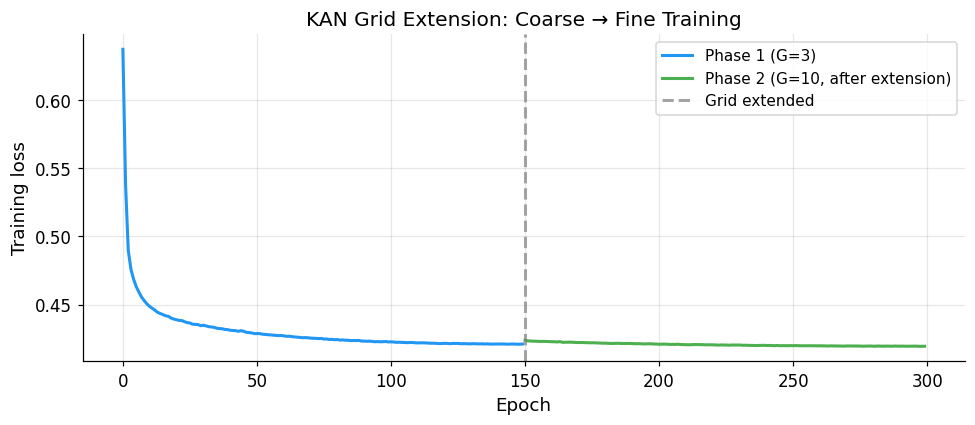

In [44]:
# ── 15. Grid extension experiment ─────────────────────────────────────────────
print('Phase 1: Training KAN on coarse grid (G=3)...')
kan_ext = KANModel(IN_DIM, KAN_HIDDEN, grid_size=3, spline_order=3)
losses_phase1 = train_pytorch(kan_ext, X_tr, y_tr, w_tr_bal,
                              epochs=150, batch_size=BATCH_SIZE,
                              lr=LR_KAN, lam_reg=KAN_LAM_REG,
                              grid_update_every=30, tag='KAN G=3')

pred_coarse = predict(kan_ext, X_te)
auc_coarse  = roc_auc_score(y_te, pred_coarse, sample_weight=w_te)
print(f'After coarse training: AUC = {auc_coarse:.4f}')

# Extend to fine grid
print('\nExtending grid from G=3 to G=10...')
X_sample = torch.tensor(X_tr[:4096], dtype=torch.float32).to(device)
kan_ext.eval()
with torch.no_grad():
    kan_ext.extend_all_grids(10, X_sample)
print(f'KAN params after extension: {count_params(kan_ext):,}')

print('\nPhase 2: Fine-tuning on extended grid (G=10)...')
losses_phase2 = train_pytorch(kan_ext, X_tr, y_tr, w_tr_bal,
                              epochs=150, batch_size=BATCH_SIZE,
                              lr=LR_KAN * 0.3, lam_reg=KAN_LAM_REG,
                              grid_update_every=0, tag='KAN G=10')

pred_fine = predict(kan_ext, X_te)
auc_fine  = roc_auc_score(y_te, pred_fine, sample_weight=w_te)
ams_fine, _ = ams_score(y_te, pred_fine, w_te)
print(f'After fine-tuning: AUC = {auc_fine:.4f}  AMS = {ams_fine:.4f}')
print(f'Improvement from extension: ΔAUC = {auc_fine - auc_coarse:+.4f}')

# Loss curve comparison
fig, ax = plt.subplots(figsize=(9, 4))
all_losses = losses_phase1 + losses_phase2
ax.plot(range(len(losses_phase1)), losses_phase1, color=COLORS[0], label='Phase 1 (G=3)')
ax.plot(range(len(losses_phase1), len(all_losses)), losses_phase2,
        color=COLORS[2], label='Phase 2 (G=10, after extension)')
ax.axvline(len(losses_phase1), color='gray', linestyle='--', alpha=0.7, label='Grid extended')
ax.set_xlabel('Epoch')
ax.set_ylabel('Training loss')
ax.set_title('KAN Grid Extension: Coarse → Fine Training')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grid_extension.pdf', bbox_inches='tight')
plt.show()

---
## 9. Learning Curves with Bootstrap Confidence Intervals

This shows how data-efficient each model is. The shaded bands are **95% bootstrap confidence intervals** — a proper measure of statistical uncertainty, not just the point estimate.

Learning curves:   0%|          | 0/7 [00:00<?, ?it/s]

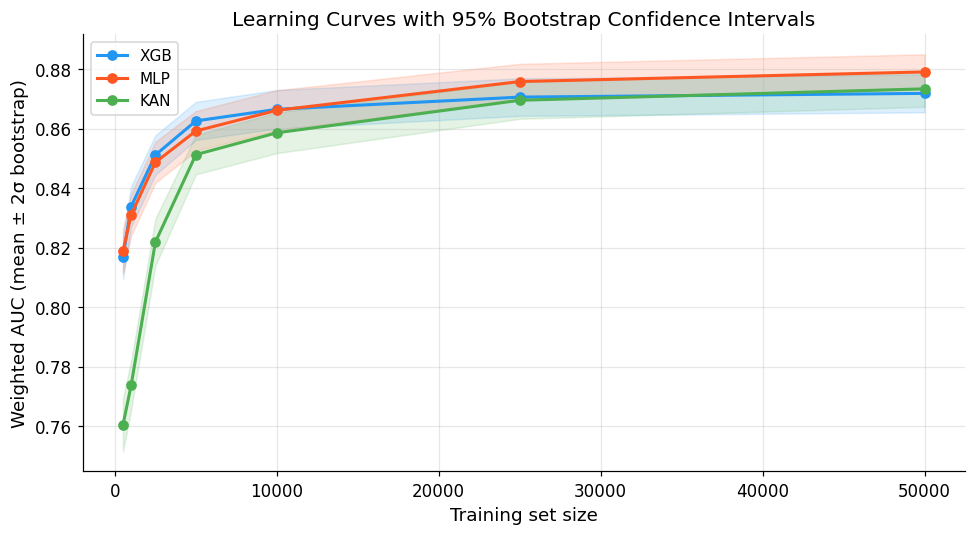

In [45]:
# ── 16. Learning curves ───────────────────────────────────────────────────────
TRAINING_SIZES = [500, 1000, 2500, 5000, 10000, 25000, 50000]
TRAINING_SIZES = [n for n in TRAINING_SIZES if n <= len(X_tr)]

lc = {m: {'auc': [], 'std': []} for m in ['xgb', 'mlp', 'kan']}
rng = np.random.default_rng(SEED)

for n in tqdm(TRAINING_SIZES, desc='Learning curves'):
    idx = rng.choice(len(X_tr), n, replace=False)
    Xn, yn, wn = X_tr[idx], y_tr[idx], w_tr_bal[idx]

    # XGBoost
    m = xgb.XGBClassifier(max_depth=4, n_estimators=300, learning_rate=0.05,
                           tree_method='hist', device='cuda' if device.type=='cuda' else 'cpu',
                           random_state=SEED, verbosity=0)
    m.fit(Xn, yn, sample_weight=wn)
    p = m.predict_proba(X_te)[:, 1]
    mu, sd, _, _ = bootstrap_eval(y_te, p, w_te, n_boot=100)
    lc['xgb']['auc'].append(mu); lc['xgb']['std'].append(sd)

    # MLP
    m = MLP(IN_DIM, [64, 32])
    train_pytorch(m, Xn, yn, wn, epochs=100, lr=LR_MLP, verbose=False)
    p = predict(m, X_te)
    mu, sd, _, _ = bootstrap_eval(y_te, p, w_te, n_boot=100)
    lc['mlp']['auc'].append(mu); lc['mlp']['std'].append(sd)

    # KAN
    m = KANModel(IN_DIM, [32, 16], grid_size=5)
    train_pytorch(m, Xn, yn, wn, epochs=100, lr=LR_KAN, lam_reg=KAN_LAM_REG, verbose=False)
    p = predict(m, X_te)
    mu, sd, _, _ = bootstrap_eval(y_te, p, w_te, n_boot=100)
    lc['kan']['auc'].append(mu); lc['kan']['std'].append(sd)

fig, ax = plt.subplots(figsize=(9, 5))
for (name, data), color in zip(lc.items(), COLORS):
    mu  = np.array(data['auc'])
    sd  = np.array(data['std'])
    ax.plot(TRAINING_SIZES[:len(mu)], mu, marker='o', color=color, label=name.upper())
    ax.fill_between(TRAINING_SIZES[:len(mu)], mu - 2*sd, mu + 2*sd, alpha=0.15, color=color)

ax.set_xlabel('Training set size')
ax.set_ylabel('Weighted AUC (mean ± 2σ bootstrap)')
ax.set_title('Learning Curves with 95% Bootstrap Confidence Intervals')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curves.pdf', bbox_inches='tight')
plt.show()

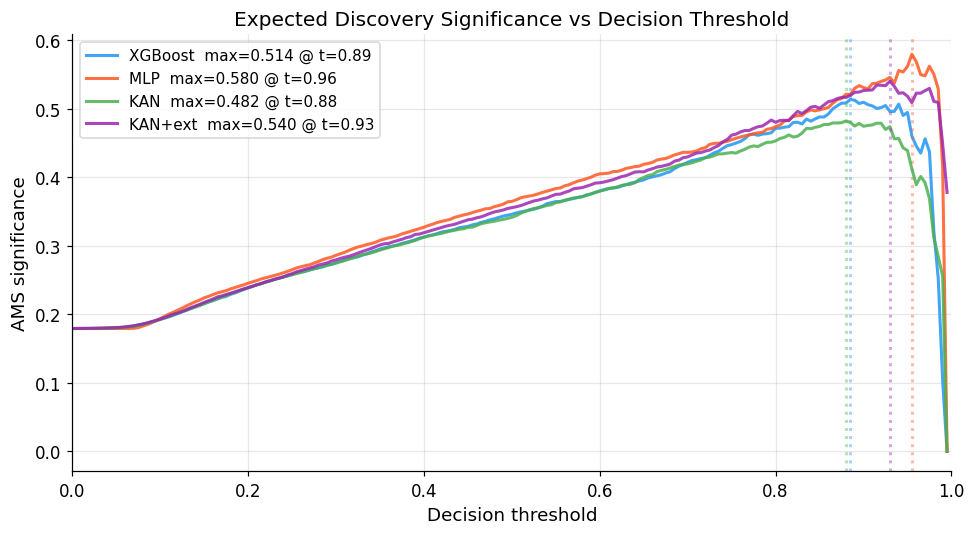

In [46]:
# ── 17. AMS significance curve ────────────────────────────────────────────────
# Shows the expected discovery significance at every possible decision threshold.
# The peak tells you the optimal operating point.

fig, ax = plt.subplots(figsize=(9, 5))
for (name, pred, color) in [
    ('XGBoost', xgb_pred, COLORS[0]),
    ('MLP',     mlp_pred, COLORS[1]),
    ('KAN',     kan_pred, COLORS[2]),
    ('KAN+ext', pred_fine, COLORS[3]),
]:
    t_vals, ams_vals = ams_vs_threshold(y_te, pred, w_te, n_bins=200)
    best_ams = ams_vals.max()
    best_t   = t_vals[ams_vals.argmax()]
    ax.plot(t_vals, ams_vals, color=color, alpha=0.85,
            label=f'{name}  max={best_ams:.3f} @ t={best_t:.2f}')
    ax.axvline(best_t, color=color, linestyle=':', alpha=0.4)

ax.set_xlabel('Decision threshold')
ax.set_ylabel('AMS significance')
ax.set_title('Expected Discovery Significance vs Decision Threshold')
ax.set_xlim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ams_curve.pdf', bbox_inches='tight')
plt.show()

---
## 10. Systematic Uncertainty Robustness

The **FAIR Universe challenge** evaluates classifiers under systematic uncertainties — unknown shifts in physics parameters that distort the input features. Here we simulate the **tau/hadronic energy scale** uncertainty: all momentum-sensitive features are multiplied by a scale factor $\gamma \in [0.8, 1.2]$.

A robust classifier should maintain high AUC even when $\gamma \neq 1$.

### Why does this matter?
In a real physics analysis, systematic uncertainties (detector calibration, theoretical modelling) shift the feature distributions. If the classifier is sensitive to these shifts, the measured signal significance will be biased — potentially leading to false discoveries or missed signals.

In [47]:
# ── 18. Robustness to systematic energy scale shifts ─────────────────────────
# Identify momentum-sensitive features (pt, mass, sum_pt, met)
MOMENTUM_KW = ['_pt', 'DER_mass', 'DER_sum', 'DER_met', 'DER_pt', 'PRI_met']
mom_idx = [i for i, f in enumerate(FEATURES)
           if any(k in f for k in MOMENTUM_KW)]
print(f'Momentum-sensitive features ({len(mom_idx)}):',
      [FEATURES[i] for i in mom_idx])

rob = {m: [] for m in ['xgb', 'mlp', 'kan', 'kan_ext']}

print(f'\n{"Shift":>6}  {"XGB":>8}  {"MLP":>8}  {"KAN":>8}  {"KAN+ext":>9}')
for s in SHIFTS:
    X_te_orig  = scaler.inverse_transform(X_te)
    X_shifted  = X_te_orig.copy()
    X_shifted[:, mom_idx] *= s
    X_sc = scaler.transform(X_shifted)

    xgb_a = roc_auc_score(y_te, xgb_model.predict_proba(X_sc)[:,1], sample_weight=w_te)
    mlp_a = roc_auc_score(y_te, predict(mlp, X_sc), sample_weight=w_te)
    kan_a = roc_auc_score(y_te, predict(kan, X_sc), sample_weight=w_te)
    ext_a = roc_auc_score(y_te, predict(kan_ext, X_sc), sample_weight=w_te)

    rob['xgb'].append(xgb_a); rob['mlp'].append(mlp_a)
    rob['kan'].append(kan_a); rob['kan_ext'].append(ext_a)
    flag = ' <-- nominal' if s == 1.0 else ''
    print(f'{s:>6.2f}  {xgb_a:>8.4f}  {mlp_a:>8.4f}  {kan_a:>8.4f}  {ext_a:>9.4f}{flag}')

nom = SHIFTS.index(1.0)
print('\nMax AUC drop from nominal (lower = more robust):')
for name, vals in rob.items():
    print(f'  {name.upper():<10}: {vals[nom] - min(vals):.4f}')

Momentum-sensitive features (15): ['DER_mass_jet_jet', 'DER_mass_transverse_met_lep', 'DER_mass_vis', 'DER_met_phi_centrality', 'DER_pt_h', 'DER_pt_ratio_lep_had', 'DER_pt_tot', 'DER_sum_pt', 'PRI_had_pt', 'PRI_jet_all_pt', 'PRI_jet_leading_pt', 'PRI_jet_subleading_pt', 'PRI_lep_pt', 'PRI_met', 'PRI_met_phi']

 Shift       XGB       MLP       KAN    KAN+ext
  0.80    0.8417    0.8285    0.8293     0.8258
  0.85    0.8552    0.8501    0.8478     0.8506
  0.90    0.8652    0.8658    0.8617     0.8662
  0.95    0.8722    0.8756    0.8706     0.8751
  1.00    0.8758    0.8797    0.8737     0.8786 <-- nominal
  1.05    0.8728    0.8774    0.8721     0.8761
  1.10    0.8641    0.8653    0.8637     0.8649
  1.15    0.8445    0.8388    0.8451     0.8392
  1.20    0.8098    0.7939    0.8135     0.7933

Max AUC drop from nominal (lower = more robust):
  XGB       : 0.0660
  MLP       : 0.0859
  KAN       : 0.0602
  KAN_EXT   : 0.0853


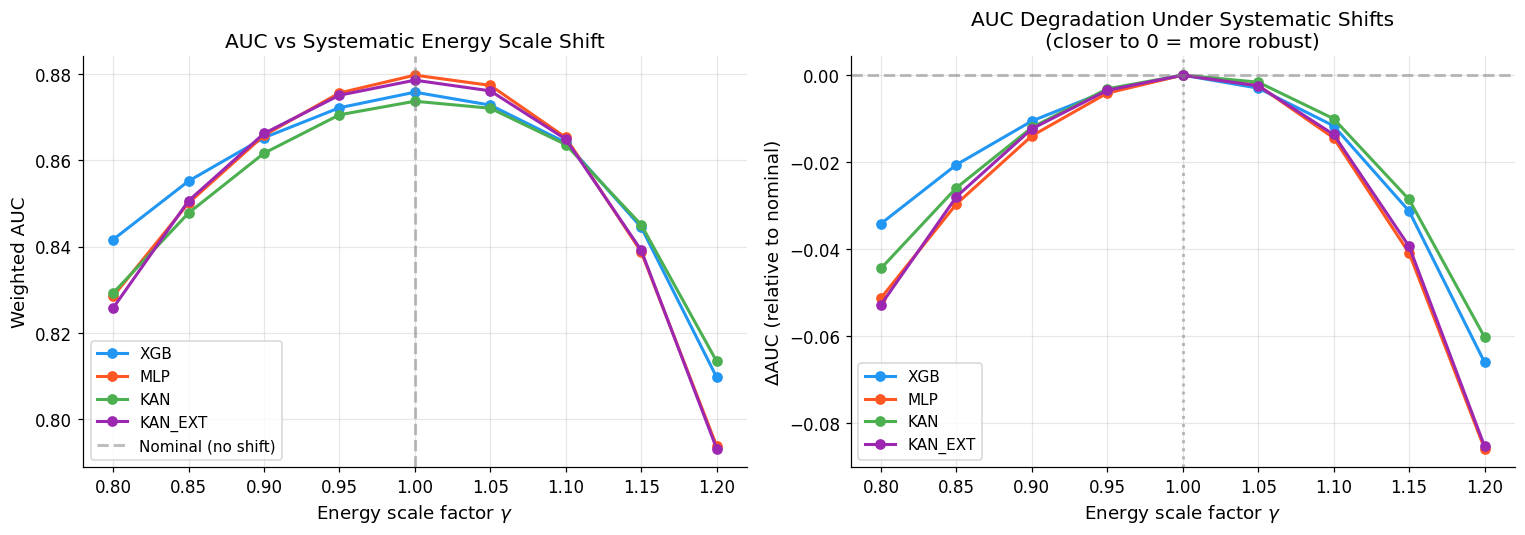

In [48]:
# ── 19. Robustness plots ──────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# AUC vs shift
for (name, vals), color in zip(rob.items(), COLORS):
    ax1.plot(SHIFTS, vals, marker='o', color=color, label=name.upper())
ax1.axvline(1.0, color='gray', linestyle='--', alpha=0.5, label='Nominal (no shift)')
ax1.set_xlabel('Energy scale factor $\\gamma$')
ax1.set_ylabel('Weighted AUC')
ax1.set_title('AUC vs Systematic Energy Scale Shift')
ax1.legend()
ax1.grid(True, alpha=0.3)

# AUC degradation (relative to nominal)
for (name, vals), color in zip(rob.items(), COLORS):
    degradation = [v - vals[nom] for v in vals]
    ax2.plot(SHIFTS, degradation, marker='o', color=color, label=name.upper())
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(1.0, color='gray', linestyle=':', alpha=0.5)
ax2.set_xlabel('Energy scale factor $\\gamma$')
ax2.set_ylabel('ΔAUC (relative to nominal)')
ax2.set_title('AUC Degradation Under Systematic Shifts\n(closer to 0 = more robust)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('robustness.pdf', bbox_inches='tight')
plt.show()

---
## 11. Adversarial Decorrelation (Nuisance Pivoting)

The **pivoting** technique (Louppe et al., 2017) trains the classifier to be *maximally uncertain* about the nuisance parameter. An adversary network tries to predict the nuisance from the classifier output; the classifier is trained to maximise classification loss while fooling the adversary.

$$\mathcal{L}_{\text{classifier}} = \mathcal{L}_{\text{BCE}} - \lambda \cdot \mathcal{L}_{\text{adversary}}$$

Here we simulate the nuisance as a discrete variable: `gamma ∈ {0.9, 1.0, 1.1}` representing the energy scale shift.

In [49]:
# ── 20. Adversarial KAN (nuisance pivoting) ───────────────────────────────────
class Adversary(nn.Module):
    """Predicts the nuisance parameter class from classifier score."""
    def __init__(self, n_nuisance_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.SiLU(),
            nn.Linear(32, 32), nn.SiLU(),
            nn.Linear(32, n_nuisance_classes)
        )

    def forward(self, score):
        return self.net(score.unsqueeze(-1))


def build_adversarial_dataset(X_tr, y_tr, w_tr, gammas=(0.9, 1.0, 1.1)):
    """Augment training data with shifted versions; label each by nuisance index."""
    Xs, ys, ws, ns = [], [], [], []
    X_orig = scaler.inverse_transform(X_tr)
    for ni, g in enumerate(gammas):
        X_s = X_orig.copy()
        X_s[:, mom_idx] *= g
        Xs.append(scaler.transform(X_s))
        ys.append(y_tr)
        ws.append(w_tr)
        ns.append(np.full(len(y_tr), ni, dtype=np.int64))
    return (np.concatenate(Xs).astype(np.float32),
            np.concatenate(ys).astype(np.float32),
            np.concatenate(ws).astype(np.float32),
            np.concatenate(ns))


GAMMAS = (0.9, 1.0, 1.1)
X_adv, y_adv, w_adv, n_adv = build_adversarial_dataset(X_tr, y_tr, w_tr_bal, GAMMAS)
print(f'Adversarial dataset: {len(X_adv):,} events ({len(GAMMAS)} gamma values)')

# Build adversarial KAN
kan_adv   = KANModel(IN_DIM, KAN_HIDDEN, KAN_GRID_SIZE, KAN_ORDER).to(device)
adversary = Adversary(len(GAMMAS)).to(device)

opt_clf  = torch.optim.Adam(kan_adv.parameters(),   lr=LR_KAN, weight_decay=1e-5)
opt_adv  = torch.optim.Adam(adversary.parameters(), lr=3e-4,   weight_decay=1e-5)
crit_clf = nn.BCEWithLogitsLoss(reduction='none')
crit_adv = nn.CrossEntropyLoss()
LAM_ADV  = 5.0   # adversarial strength (higher = more robust, less accurate)

Xa_t = torch.tensor(X_adv, dtype=torch.float32).to(device)
ya_t = torch.tensor(y_adv, dtype=torch.float32).to(device)
wa_t = torch.tensor(w_adv, dtype=torch.float32).to(device)
na_t = torch.tensor(n_adv, dtype=torch.long).to(device)
wa_t = wa_t / wa_t.mean()

adv_loader = DataLoader(TensorDataset(Xa_t, ya_t, wa_t, na_t),
                        batch_size=BATCH_SIZE * 2, shuffle=True)
adv_losses, clf_losses = [], []
EPOCHS_ADV = 150

# Two separate GradScalers — one per optimizer / backward pass
clf_scaler = GradScaler(device='cuda', enabled=USE_AMP)
adv_scaler = GradScaler(device='cuda', enabled=USE_AMP)

print(f'\nAdversarial training ({EPOCHS_ADV} epochs, lambda={LAM_ADV})...')
for ep in tqdm(range(1, EPOCHS_ADV + 1), desc='Adv KAN'):
    kan_adv.train(); adversary.train()

    ep_clf, ep_adv = 0.0, 0.0
    for Xb, yb, wb, nb in adv_loader:
        # Step 1: train adversary (classifier frozen)
        with torch.no_grad():
            with autocast('cuda', enabled=USE_AMP):
                score = torch.sigmoid(kan_adv(Xb))
        opt_adv.zero_grad()
        with autocast('cuda', enabled=USE_AMP):
            adv_pred = adversary(score)
            loss_adv = crit_adv(adv_pred, nb)
        adv_scaler.scale(loss_adv).backward()
        adv_scaler.step(opt_adv)
        adv_scaler.update()

        # Step 2: train classifier to classify AND fool adversary
        opt_clf.zero_grad()
        with autocast('cuda', enabled=USE_AMP):
            logits = kan_adv(Xb)
            score  = torch.sigmoid(logits)
            loss_c = (crit_clf(logits, yb) * wb).mean()
            loss_a = crit_adv(adversary(score), nb)
            total  = loss_c - LAM_ADV * loss_a   # minimise BCE, maximise adversary confusion
        clf_scaler.scale(total).backward()
        clf_scaler.unscale_(opt_clf)
        nn.utils.clip_grad_norm_(kan_adv.parameters(), 1.0)
        clf_scaler.step(opt_clf)
        clf_scaler.update()
        ep_clf += loss_c.item(); ep_adv += loss_a.item()

    clf_losses.append(ep_clf / len(adv_loader))
    adv_losses.append(ep_adv / len(adv_loader))

kan_adv_pred = predict(kan_adv, X_te)
adv_auc, adv_ams, _, _ = evaluate('KAN-Adversarial', y_te, kan_adv_pred, w_te)

Adversarial dataset: 209,997 events (3 gamma values)

Adversarial training (150 epochs, lambda=5.0)...


Adv KAN:   0%|          | 0/150 [00:00<?, ?it/s]

KAN-Adversarial           AUC=0.8740   AMS=0.4996  (cut=0.975)


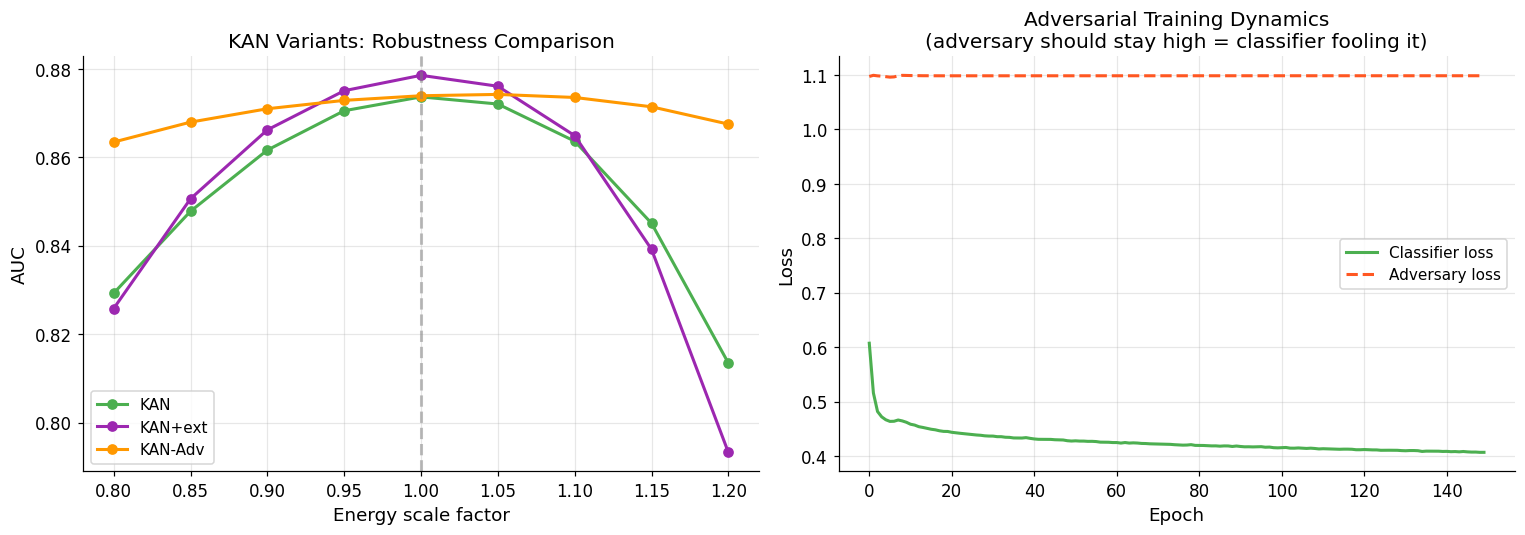


AUC @ nominal:   KAN=0.8737  KAN-Adv=0.8740
Max AUC drop:    KAN=0.0602   KAN-Adv=0.0105
Tradeoff: adversarial training reduces robustness degradation at some cost in nominal AUC.


In [50]:
# ── 21. Adversarial robustness comparison ─────────────────────────────────────
adv_rob = []
for s in SHIFTS:
    X_te_orig = scaler.inverse_transform(X_te)
    X_s = X_te_orig.copy()
    X_s[:, mom_idx] *= s
    X_sc = scaler.transform(X_s)
    adv_rob.append(roc_auc_score(y_te, predict(kan_adv, X_sc), sample_weight=w_te))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Robustness comparison: KAN vs KAN-adv
for (name, vals), color in zip(
    [('KAN', rob['kan']), ('KAN+ext', rob['kan_ext']), ('KAN-Adv', adv_rob)],
    COLORS[2:]
):
    ax1.plot(SHIFTS, vals, marker='o', color=color, label=name)
ax1.axvline(1.0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('Energy scale factor'); ax1.set_ylabel('AUC')
ax1.set_title('KAN Variants: Robustness Comparison')
ax1.legend(); ax1.grid(True, alpha=0.3)

# Adversarial training loss curves
ax2.plot(clf_losses, label='Classifier loss', color=COLORS[2])
ax2.plot(adv_losses, label='Adversary loss', color=COLORS[1], linestyle='--')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.set_title('Adversarial Training Dynamics\n(adversary should stay high = classifier fooling it)')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('adversarial.pdf', bbox_inches='tight')
plt.show()

print(f'\nAUC @ nominal:   KAN={rob["kan"][nom]:.4f}  KAN-Adv={adv_rob[nom]:.4f}')
print(f'Max AUC drop:    KAN={rob["kan"][nom]-min(rob["kan"]):.4f}  ',
      f'KAN-Adv={adv_rob[nom]-min(adv_rob):.4f}')
print('Tradeoff: adversarial training reduces robustness degradation at some cost in nominal AUC.')

---
## 12. KAN Interpretability

KAN's key advantage: every edge learns a **visualisable 1-D function**. Unlike MLP weights (which are just numbers), spline activations can be plotted, compared to known physics functions, and potentially simplified via symbolic regression.

**What to look for:**
- A **threshold shape** (step function) on a mass feature → KAN learned a mass window cut
- A **linear** activation → that edge contributes linearly
- A **near-zero flat** activation → that feature is unimportant; prune this edge
- A shape resembling $\log$ or $\exp$ → may be capturing known physics scaling

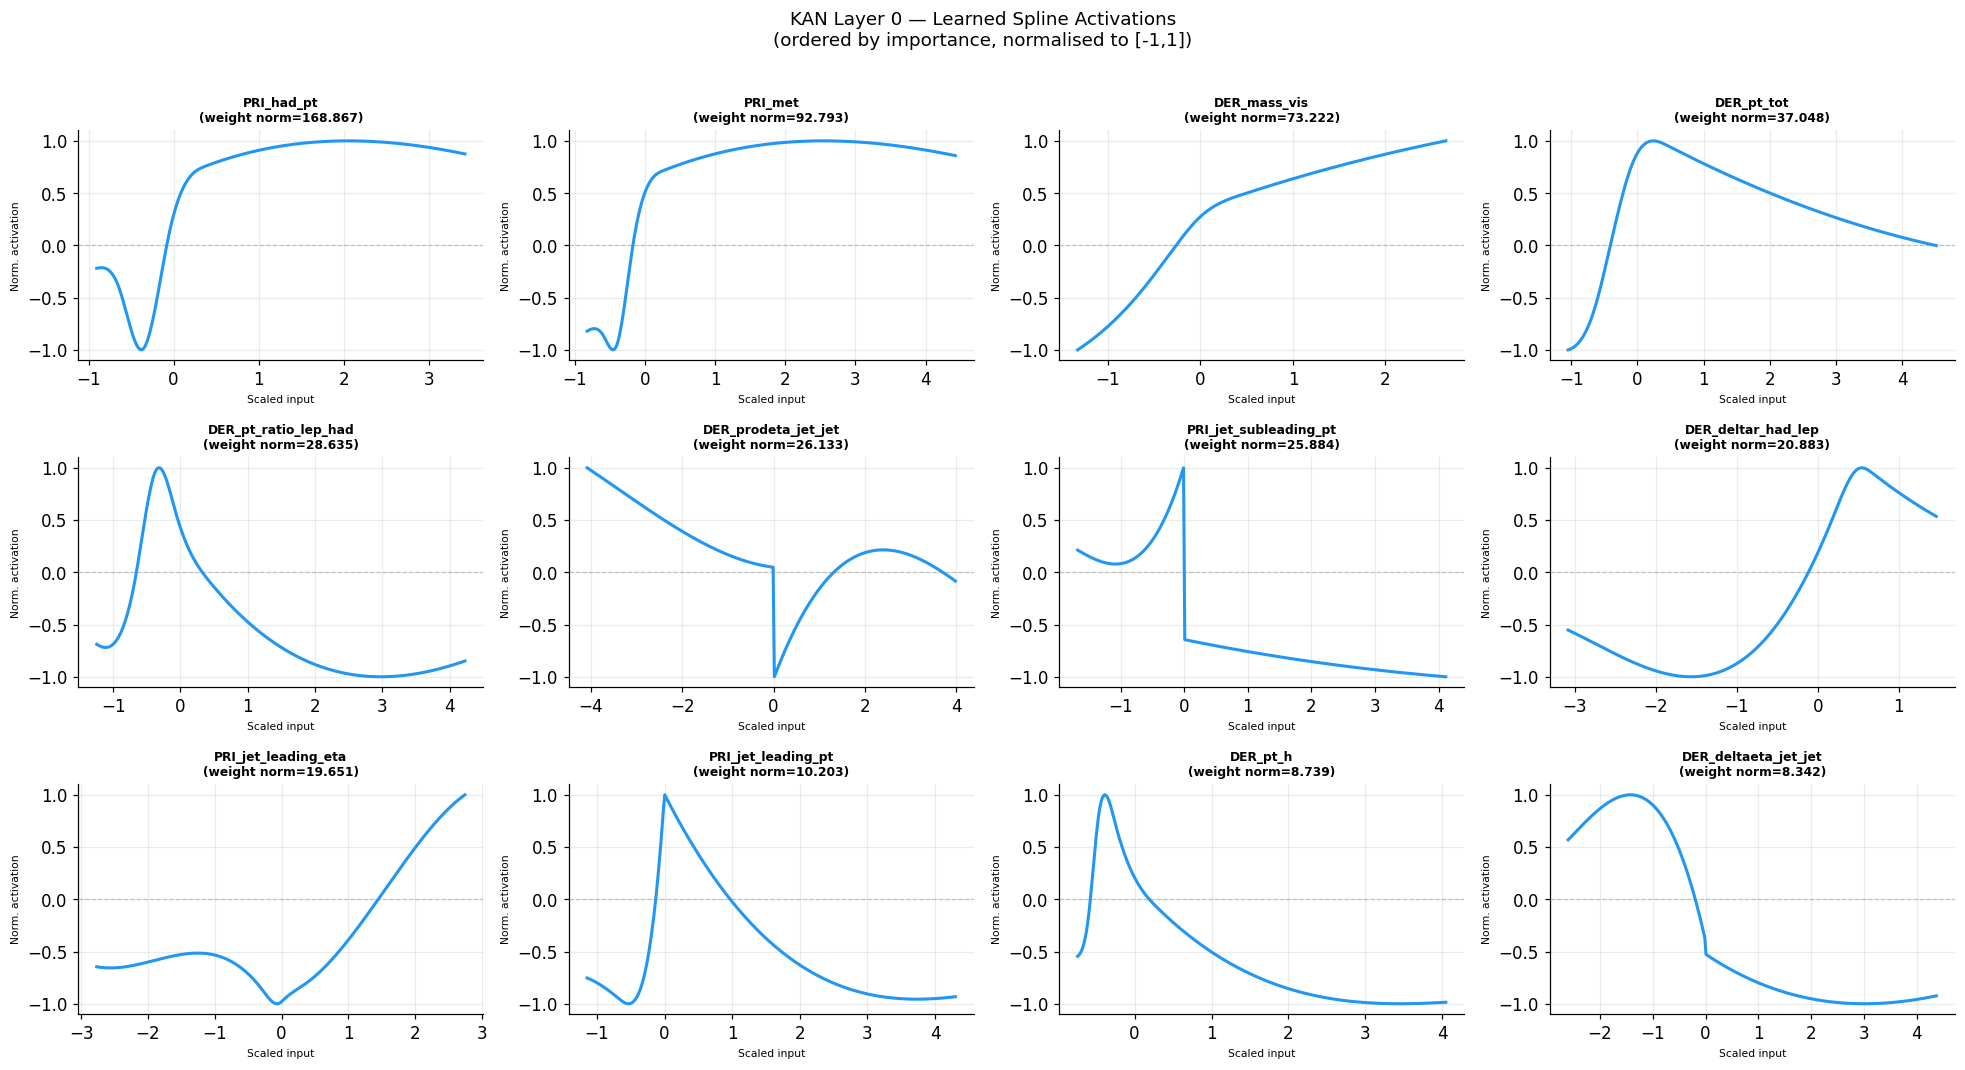

In [51]:
# ── 22. Visualise KAN spline activations (Layer 0) ───────────────────────────
def plot_spline_activations(model, X_sample, feature_names,
                            layer_idx=0, n_show=12, n_cols=4):
    """Plot the learned 1-D spline function for each input feature."""
    kan_layers = [l for l in model.hidden if isinstance(l, KANLayer)]
    if layer_idx >= len(kan_layers):
        print(f'Only {len(kan_layers)} KAN layers available.')
        return
    kl   = kan_layers[layer_idx]
    X_t  = torch.tensor(X_sample, dtype=torch.float32).to(device)
    mean = X_t.mean(dim=0, keepdim=True)

    n_show = min(n_show, kl.in_features)
    n_rows = (n_show + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.2 * n_rows))
    axes = np.array(axes).flatten()

    kl.eval()
    with torch.no_grad():
        # Compute spline weight norms for ordering (most to least important)
        importance = kl.spline_weight.pow(2).sum(dim=[1, 2]).cpu().numpy()
        order      = np.argsort(importance)[::-1]

        for plot_i, feat_i in enumerate(order[:n_show]):
            x_lo = float(X_t[:, feat_i].quantile(0.01))
            x_hi = float(X_t[:, feat_i].quantile(0.99))
            x_r  = torch.linspace(x_lo, x_hi, 300, device=device)
            probe = mean.expand(300, -1).clone()
            probe[:, feat_i] = x_r

            B  = kl._bases(probe)                                         # (300, in, G+k)
            sp = torch.einsum('bik,iko->bio', B, kl.spline_weight)        # (300, in, out)
            # Sum spline contribution for this feature over all outputs
            act = sp[:, feat_i, :].sum(dim=-1).cpu().numpy()

            # Normalise to [-1, 1] for visual comparison
            rng = act.max() - act.min() + 1e-8
            act_norm = (act - act.min()) / rng * 2 - 1

            ax = axes[plot_i]
            ax.plot(x_r.cpu().numpy(), act_norm, color=COLORS[0], linewidth=2)
            ax.axhline(0, color='gray', linestyle='--', alpha=0.4, linewidth=0.8)

            fname = feature_names[feat_i]
            imp   = importance[feat_i]
            ax.set_title(f'{fname}\n(weight norm={imp:.3f})', fontsize=8, fontweight='bold')
            ax.set_xlabel('Scaled input', fontsize=7)
            ax.set_ylabel('Norm. activation', fontsize=7)
            ax.grid(True, alpha=0.25)

        for j in range(n_show, len(axes)):
            axes[j].set_visible(False)

    plt.suptitle(f'KAN Layer {layer_idx} — Learned Spline Activations\n'
                 f'(ordered by importance, normalised to [-1,1])', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(f'kan_splines_layer{layer_idx}.pdf', bbox_inches='tight')
    plt.show()


plot_spline_activations(kan, X_te[:3000], FEATURES, layer_idx=0, n_show=12, n_cols=4)

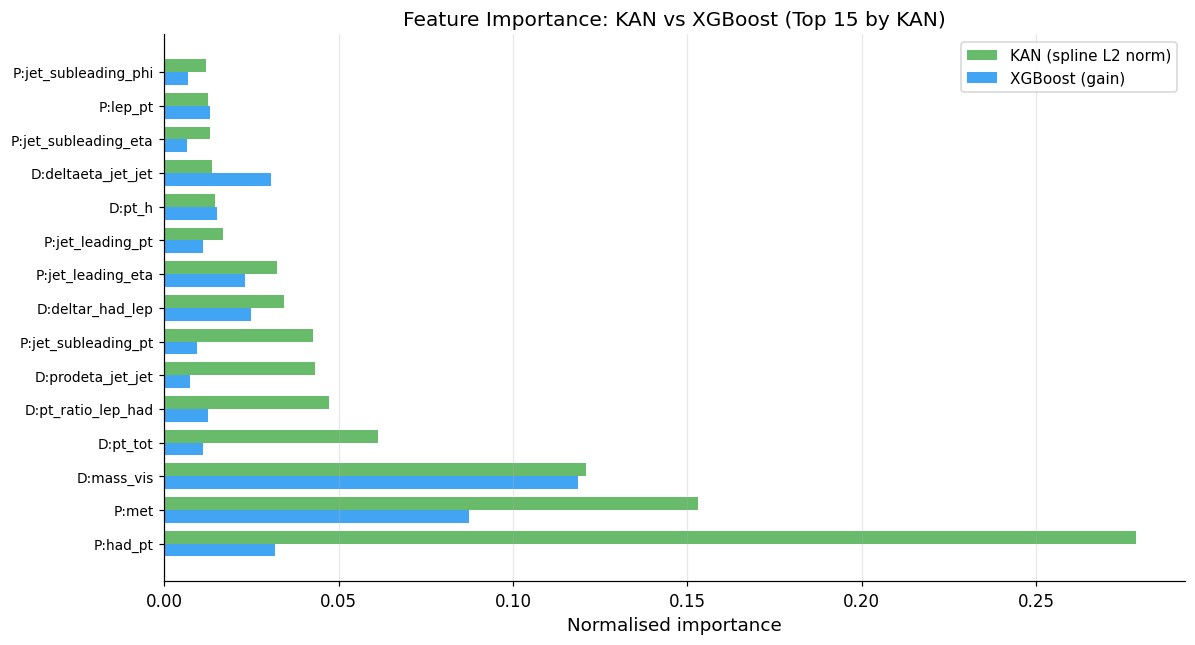


Top 5 features by KAN importance:
  PRI_had_pt                           KAN=0.2787   XGB=0.0318
  PRI_met                              KAN=0.1532   XGB=0.0875
  DER_mass_vis                         KAN=0.1209   XGB=0.1185
  DER_pt_tot                           KAN=0.0611   XGB=0.0112
  DER_pt_ratio_lep_had                 KAN=0.0473   XGB=0.0124


In [52]:
# ── 23. Feature importance: KAN vs XGBoost ────────────────────────────────────
# KAN importance: L2 norm of spline weights in layer 0
kl0 = [l for l in kan.hidden if isinstance(l, KANLayer)][0]
with torch.no_grad():
    kan_imp = kl0.spline_weight.pow(2).sum(dim=[1, 2]).cpu().numpy()
kan_imp = kan_imp / kan_imp.sum()   # normalise to fractions

# XGBoost importance (gain)
xgb_imp_raw = xgb_model.get_booster().get_score(importance_type='gain')
xgb_imp = np.array([xgb_imp_raw.get(f'f{i}', 0) for i in range(len(FEATURES))])
xgb_imp = xgb_imp / (xgb_imp.sum() + 1e-8)

# Top-15 features by KAN importance
top15 = np.argsort(kan_imp)[::-1][:15]
feat_names_short = [FEATURES[i].replace('PRI_','P:').replace('DER_','D:') for i in top15]

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(15)
w = 0.38
ax.barh(x + w/2, kan_imp[top15],  height=w, color=COLORS[2], alpha=0.85, label='KAN (spline L2 norm)')
ax.barh(x - w/2, xgb_imp[top15], height=w, color=COLORS[0], alpha=0.85, label='XGBoost (gain)')
ax.set_yticks(x)
ax.set_yticklabels(feat_names_short, fontsize=9)
ax.set_xlabel('Normalised importance')
ax.set_title('Feature Importance: KAN vs XGBoost (Top 15 by KAN)')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance.pdf', bbox_inches='tight')
plt.show()

print('\nTop 5 features by KAN importance:')
for i in top15[:5]:
    print(f'  {FEATURES[i]:<35s}  KAN={kan_imp[i]:.4f}   XGB={xgb_imp[i]:.4f}')

Hyperparameter sweep: 4 grid sizes × 3 orders = 12 runs
  G= 3  k=2  params=  8,513  AUC=0.8757
  G= 3  k=3  params=  9,921  AUC=0.8762
  G= 3  k=4  params= 11,329  AUC=0.8747
  G= 5  k=2  params= 11,329  AUC=0.8730
  G= 5  k=3  params= 12,737  AUC=0.8744
  G= 5  k=4  params= 14,145  AUC=0.8759
  G= 8  k=2  params= 15,553  AUC=0.8655
  G= 8  k=3  params= 16,961  AUC=0.8703
  G= 8  k=4  params= 18,369  AUC=0.8710
  G=12  k=2  params= 21,185  AUC=0.8561
  G=12  k=3  params= 22,593  AUC=0.8551
  G=12  k=4  params= 24,001  AUC=0.8635


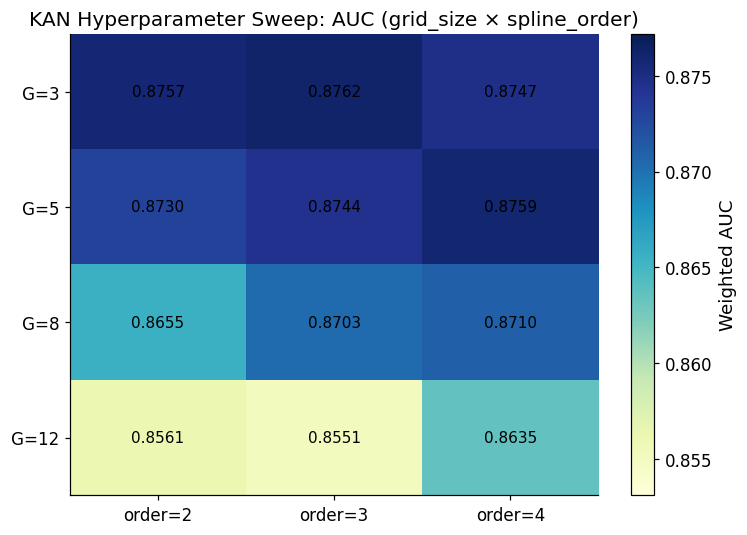


Best: grid_size=3, spline_order=3, AUC=0.8762


In [55]:
# ── 24. KAN Hyperparameter sweep: grid_size × spline_order ───────────────────
# Systematically test which KAN configuration works best for this dataset.
# This is the kind of analysis missing from the prior notebook.

GRID_SIZES    = [3, 5, 8, 12]
SPLINE_ORDERS = [2, 3, 4]
SWEEP_EPOCHS  = 100

sweep_results = np.zeros((len(GRID_SIZES), len(SPLINE_ORDERS)))
print(f'Hyperparameter sweep: {len(GRID_SIZES)} grid sizes × {len(SPLINE_ORDERS)} orders '
      f'= {len(GRID_SIZES)*len(SPLINE_ORDERS)} runs')

for gi, G in enumerate(GRID_SIZES):
    for ki, k in enumerate(SPLINE_ORDERS):
        m = KANModel(IN_DIM, [32, 16], grid_size=G, spline_order=k)
        train_pytorch(m, X_tr, y_tr, w_tr_bal,
                      epochs=SWEEP_EPOCHS, lr=LR_KAN,
                      lam_reg=KAN_LAM_REG, verbose=False)
        p   = predict(m, X_te)
        auc = roc_auc_score(y_te, p, sample_weight=w_te)
        sweep_results[gi, ki] = auc
        print(f'  G={G:>2d}  k={k}  params={count_params(m):>7,}  AUC={auc:.4f}')

# Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(sweep_results, cmap='YlGnBu', aspect='auto',
               vmin=sweep_results.min() - 0.002, vmax=sweep_results.max() + 0.001)
plt.colorbar(im, ax=ax, label='Weighted AUC')
ax.set_xticks(range(len(SPLINE_ORDERS))); ax.set_xticklabels([f'order={k}' for k in SPLINE_ORDERS])
ax.set_yticks(range(len(GRID_SIZES)));    ax.set_yticklabels([f'G={G}' for G in GRID_SIZES])
for gi in range(len(GRID_SIZES)):
    for ki in range(len(SPLINE_ORDERS)):
        ax.text(ki, gi, f'{sweep_results[gi,ki]:.4f}', ha='center', va='center', fontsize=10)
ax.set_title('KAN Hyperparameter Sweep: AUC (grid_size × spline_order)')
plt.tight_layout()
plt.savefig('hyperparameter_sweep.pdf', bbox_inches='tight')
plt.show()

best_gi, best_ki = np.unravel_index(sweep_results.argmax(), sweep_results.shape)
print(f'\nBest: grid_size={GRID_SIZES[best_gi]}, spline_order={SPLINE_ORDERS[best_ki]}, '
      f'AUC={sweep_results[best_gi,best_ki]:.4f}')

---
## 13. Final Results Summary

In [56]:
# ── 25. Complete results table ────────────────────────────────────────────────
all_models = [
    ('XGBoost',       xgb_pred,     '—'),
    ('MLP',           mlp_pred,     f'{count_params(mlp):,}'),
    ('KAN (base)',    kan_pred,     f'{count_params(kan):,}'),
    ('KAN+extension', pred_fine,    f'{count_params(kan_ext):,}'),
    ('KAN-Adversarial', kan_adv_pred, f'{count_params(kan_adv):,}'),
]

print('\n' + '='*80)
print(f'{"Model":<22}  {"Params":>10}  {"AUC":>8}  {"±":>6}  {"AMS":>8}  {"±":>6}  {"MaxDrop":>8}')
print('='*80)

for name, pred, params in all_models:
    auc_m, auc_s, ams_m, ams_s = bootstrap_eval(y_te, pred, w_te, n_boot=200)
    # Robustness: re-compute for this model
    drops = []
    for s in SHIFTS:
        X_te_orig = scaler.inverse_transform(X_te)
        X_s = X_te_orig.copy()
        X_s[:, mom_idx] *= s
        X_sc = scaler.transform(X_s)
        if 'XGBoost' in name:
            p_s = xgb_model.predict_proba(X_sc)[:, 1]
        elif 'MLP' in name:
            p_s = predict(mlp, X_sc)
        elif 'Adversarial' in name:
            p_s = predict(kan_adv, X_sc)
        elif 'extension' in name:
            p_s = predict(kan_ext, X_sc)
        else:
            p_s = predict(kan, X_sc)
        drops.append(roc_auc_score(y_te, p_s, sample_weight=w_te))
    max_drop = drops[nom] - min(drops)
    print(f'{name:<22}  {params:>10}  {auc_m:>8.4f}  {auc_s:>6.4f}  '
          f'{ams_m:>8.4f}  {ams_s:>6.4f}  {max_drop:>8.4f}')

print('='*80)
print('MaxDrop = AUC drop from nominal under energy scale shifts (lower = more robust)')


Model                       Params       AUC       ±       AMS       ±   MaxDrop
XGBoost                          —    0.8760  0.0031    0.5535  0.0622    0.0660
MLP                         14,529    0.8799  0.0030    0.6163  0.0787    0.0859
KAN (base)                  34,689    0.8739  0.0033    0.4927  0.0255    0.0602
KAN+extension               53,889    0.8788  0.0030    0.5759  0.0521    0.0853
KAN-Adversarial             34,689    0.8741  0.0032    0.5290  0.0449    0.0105
MaxDrop = AUC drop from nominal under energy scale shifts (lower = more robust)


---
## 14. Next Steps & Open Questions

### Immediate improvements
- [ ] **Tune adversarial strength `λ`** — sweep over `[1, 5, 20, 50]` to find the accuracy/robustness Pareto frontier
- [ ] **Symbolic regression** — try `pykan`'s `suggest_symbolic()` on the most important KAN edges to find closed-form physics expressions
- [ ] **Grid extension schedule** — `G=3→5→8→12` in stages instead of one jump
- [ ] **Cross-validation** — 5-fold CV to get reliable uncertainty estimates on AUC

### Research questions
1. **Does KAN interpretability reveal known physics?**  
   Plot the activation of `DER_mass_vis` — does it look like a window around 125 GeV (Higgs mass)?

2. **Is KAN inherently more robust to systematics than MLP?**  
   The smooth spline functions might generalise better under smooth feature shifts.

3. **Can we combine KAN with profile likelihood?**  
   Replace the simple AMS with a proper profile likelihood ratio test statistic.

4. **KAN 2.0** (arXiv:2408.10205): MultKAN adds multiplicative interactions — potentially more expressive for physics where products of variables appear naturally (e.g. $p_T \times \eta$).

### References
- Liu et al., *KAN: Kolmogorov-Arnold Networks*, arXiv:2404.19756 (2024)
- Liu et al., *KAN 2.0*, arXiv:2408.10205 (2024)
- Louppe et al., *Learning to Pivot with Adversarial Networks*, NeurIPS 2017
- Cowan et al., *Asymptotic formulae for likelihood-based tests of new physics*, arXiv:1007.1727
- FAIR Universe HiggsML Challenge: https://fair-universe.lbl.gov